## Model Training with PCA

**Goal:** Train and compare multiple machine learning models using the engineered features and PCA.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor


def make_one_hot_encoder():
    """Compatibility helper for different scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


train = pd.read_csv(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\UK_House_Price_Prediction_Model\train_features.csv')

print('Loaded train_features:', train.shape)

Loaded train_features: (1460, 90)


#### Prepare features and target

We use `log1p(SalePrice)` as the target because house prices are right-skewed.

Later, predictions are converted back using `expm1()`.

In [3]:
y = np.log1p(train['SalePrice'])
X = train.drop(columns=['SalePrice', 'Id'])

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training rows:', X_train.shape[0])
print('Validation rows:', X_valid.shape[0])
print('Numeric columns:', len(numeric_features))
print('Categorical columns:', len(categorical_features))

Training rows: 1168
Validation rows: 292
Numeric columns: 45
Categorical columns: 43


#### Build common preprocessing

This must match Notebook 03:

- Numeric: median imputation + scaling.
- Categorical: missing imputation + one-hot encoding.
- PCA: keeps 95% of variance for the study version.

In [5]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', make_one_hot_encoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

#### Evaluation function

We evaluate on the original dollar scale, not only on the log scale.

Metrics:

- **MAE**: average absolute error.
- **RMSE**: penalizes large errors more strongly.
- **R²**: proportion of variance explained by the model.

In [7]:
def evaluate_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    pred_log = pipeline.predict(X_valid)
    pred = np.expm1(pred_log)
    actual = np.expm1(y_valid)
    
    return {
        'Model': name,
        'MAE': mean_absolute_error(actual, pred),
        'RMSE': np.sqrt(mean_squared_error(actual, pred)),
        'R2': r2_score(actual, pred)
    }

#### Model comparison with PCA

We compare:

1. Baseline mean model.
2. Ridge Regression + PCA.
3. Random Forest + PCA.
4. Histogram Gradient Boosting + PCA.

For this study project, PCA is included in the modelling workflow.

In [ ]:
models = {
    'Baseline Mean': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', DummyRegressor(strategy='mean'))
    ]),
    'Ridge + PCA': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('pca', PCA(n_components=0.95, random_state=42)),
        ('model', Ridge(alpha=10))
    ]),
    'Random Forest + PCA': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('pca', PCA(n_components=0.95, random_state=42)),
        ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    'Hist Gradient Boosting + PCA': Pipeline(steps=[
        ('preprocess', preprocessor),
        ('pca', PCA(n_components=0.95, random_state=42)),
        ('model', HistGradientBoostingRegressor(random_state=42))
    ])
}

results = [evaluate_model(name, pipe) for name, pipe in models.items()]
results_df = pd.DataFrame(results).sort_values('RMSE')
display(results_df)

plt.figure(figsize=(8, 5))
plt.barh(results_df['Model'], results_df['RMSE'])
plt.gca().invert_yaxis()
plt.title('Model Comparison by RMSE')
plt.xlabel('RMSE')
plt.show()

#### Cross-validation

A single validation split can be lucky or unlucky.

Cross-validation trains and validates the model multiple times on different folds, giving a more reliable estimate.

In [10]:
ridge_pca = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('model', Ridge(alpha=10))
])

cv_scores = cross_validate(
    ridge_pca,
    X,
    y,
    cv=5,
    scoring=['neg_root_mean_squared_error', 'r2'],
    n_jobs=-1
)

print('CV RMSE on log target:', -cv_scores['test_neg_root_mean_squared_error'])
print('Mean CV RMSE on log target:', -cv_scores['test_neg_root_mean_squared_error'].mean())
print('Mean CV R2:', cv_scores['test_r2'].mean())

CV RMSE on log target: [0.12656397 0.15889484 0.1381562  0.12518683 0.19440056]
Mean CV RMSE on log target: 0.1486404803643559
Mean CV R2: 0.8567954100913722


#### Hyperparameter tuning

Hyperparameters are model settings chosen before training.

Here we tune:

- `pca__n_components`: how much variance PCA keeps.
- `model__alpha`: Ridge regularization strength.

In [12]:
ridge_pca = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('pca', PCA(random_state=42)),
    ('model', Ridge())
])

param_grid = {
    'pca__n_components': [0.90, 0.95, 0.98],
    'model__alpha': [0.1, 1, 5, 10, 20, 50, 100]
}

search = RandomizedSearchCV(
    ridge_pca,
    param_distributions=param_grid,
    n_iter=12,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print('Best parameters:', search.best_params_)
print('Best CV RMSE on log target:', -search.best_score_)

best_model = search.best_estimator_
pred_log = best_model.predict(X_valid)
pred = np.expm1(pred_log)
actual = np.expm1(y_valid)

print('Validation MAE:', mean_absolute_error(actual, pred))
print('Validation RMSE:', np.sqrt(mean_squared_error(actual, pred)))
print('Validation R2:', r2_score(actual, pred))

Best parameters: {'pca__n_components': 0.98, 'model__alpha': 50}
Best CV RMSE on log target: 0.14725657151481253
Validation MAE: 17243.59139278696
Validation RMSE: 26469.969959253845
Validation R2: 0.9086532579295936


#### Predicted vs actual plot

If predictions are perfect, points will fall on the diagonal line.

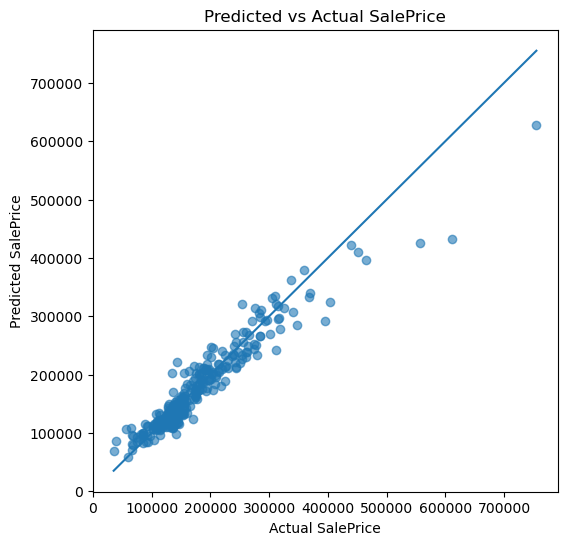

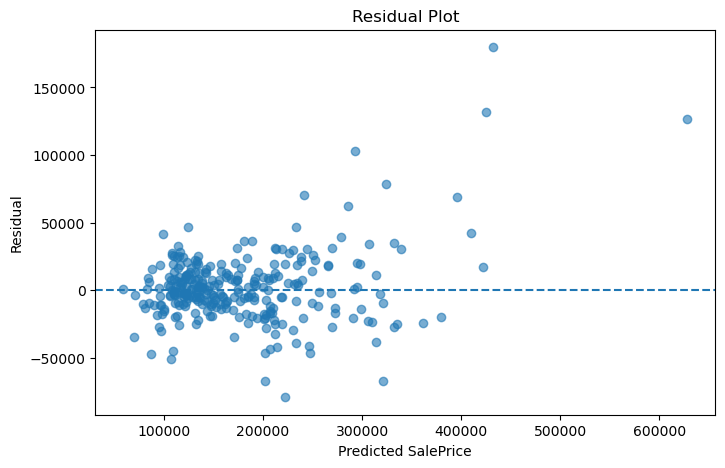

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(actual, pred, alpha=0.6)
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()])
plt.title('Predicted vs Actual SalePrice')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.show()

residuals = actual - pred
plt.figure(figsize=(8, 5))
plt.scatter(pred, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted SalePrice')
plt.ylabel('Residual')
plt.show()

- Trained multiple regression models using PCA.
- Compared model performance using MAE, RMSE, and R².
- Used cross-validation to get a more reliable estimate.
- Tuned Ridge + PCA hyperparameters.
- Visualized predicted vs actual prices.